# Aula 03 — Métodos Baseados em Políticas
## Notebook 01 — Intuição de política: aprender o comportamento diretamente

**Disciplina:** Modelos de Aprendizagem por Reforço  
**Tema:** Motivação para policy-based, política parametrizada, comparação com value-based  
**Ambiente:** CartPole-v1

| | |
|---|---|
| **Aula** | Aula 03 — Métodos Baseados em Políticas |
| **Notebook** | 01 — Intuição de Política |
| **Seções** | 3.1 |
| **Tempo de leitura** | ~10 min |
| **Tempo de execução** | ~2 min |

**Pré-requisitos:** Aula 02 (Value-Based Methods); conceito de política e espaço de ações.

**Competências para o Desafio Final:** Distinguir métodos value-based de policy-based; identificar quando cada abordagem é mais adequada ao problema.

### Recapitulando

A Aula 02 percorreu seis métodos baseados em valor — de Programação Dinâmica ao DQN — todos com o mesmo ponto cego: o espaço de ações precisa ser discreto e enumerável, porque a política é derivada de `argmax_a Q(s,a)`. O próximo passo natural é: **e quando as ações são contínuas?** Este notebook apresenta a mudança de objeto: da função de valor para a política parametrizada diretamente.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))

import rl_utils
rl_utils.info_versoes()
rl_utils.configurar_matplotlib()
rl_utils.definir_seeds(42)

Biblioteca           Versão
--------------------------------
gymnasium            1.0.0


torch                2.11.0+cpu
numpy                2.4.2
matplotlib           3.10.8
pandas               3.0.1


scikit-learn         1.8.0


## Bloco 1 — Contexto e pergunta

A Aula 02 mostrou como aprender funções de valor e derivar políticas a partir delas. Todos os métodos — de Q-Learning ao DQN — dependem de uma operação central:

    π(s) = argmax_a Q(s,a)

Essa operação exige **enumerar todas as ações possíveis**. Em robótica e controle, as ações são contínuas — há infinitas possibilidades — e essa enumeração se torna inviável.

A pergunta que guia esta aula é:

> **E se o agente aprendesse *diretamente* como se comportar, sem passar por uma função de valor?**

A resposta é parametrizar a política como uma função diferenciável e otimizar seus parâmetros diretamente para maximizar o retorno esperado.

**Mensagem principal:**
> *Em métodos policy-based, o agente não pergunta qual estado vale mais — ele pergunta como deve se comportar.*

In [2]:
# Instalação opcional das dependências
# %pip install numpy matplotlib gymnasium

In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

env = gym.make("CartPole-v1")
obs, _ = env.reset(seed=SEED)

print("Versões utilizadas:")
print(f"  numpy: {np.__version__}")
print(f"  gymnasium: {gym.__version__}")
print(f"  matplotlib: {plt.matplotlib.__version__}")
print()
print("Espaço de observações:", env.observation_space)
print("Espaço de ações:", env.action_space)
print()
nomes = ["posição do carrinho", "velocidade do carrinho", "ângulo do polo", "vel. angular do polo"]
print("Observação inicial (4 dimensões contínuas):")
for nome, val in zip(nomes, obs):
    print(f"  {nome}: {val:.4f}")

Versões utilizadas:
  numpy: 2.4.2
  gymnasium: 1.0.0
  matplotlib: 3.10.8

Espaço de observações: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Espaço de ações: Discrete(2)

Observação inicial (4 dimensões contínuas):
  posição do carrinho: 0.0274
  velocidade do carrinho: -0.0061
  ângulo do polo: 0.0359
  vel. angular do polo: 0.0197


## Bloco 2 — Mini teoria: a política como objeto de aprendizado

Nos métodos value-based, a política é **implícita** — derivada de Q(s,a):

    π(s) = argmax_a Q(s,a)   ← requer enumerar todas as ações

Nos métodos policy-based, a política é **explícita** — parametrizada diretamente:

    π(a | s; θ)  =  distribuição de probabilidade sobre ações

O objetivo é encontrar θ que maximize o retorno esperado:

    J(θ) = E_{τ ~ π_θ}[R(τ)]   onde   R(τ) = Σ_t r_t

Com ações contínuas, π pode ser uma Gaussiana: π(a|s;θ) = N(μ(s;θ), σ(s;θ)). O agente produz um valor real — torque, ângulo, força — sem enumerar opções.

In [4]:
print("Value-based:")
print("  π(s) = argmax_a Q(s,a)  →  enumera todas as ações")
print("  Inviável para ações contínuas")
print()
print("Policy-based:")
print("  π(a|s; θ)  →  distribuição parametrizada diretamente")
print("  Objetivo: max J(θ) = E[retorno] — otimizável por gradiente ascendente")
print("  Ações contínuas: π pode ser Gaussiana com média e desvio parametrizados")
print()
print("CartPole-v1: ações discretas (0=esquerda, 1=direita) — ambiente simples para a intuição.")
print("A generalização para ações contínuas vem no Notebook 05 (Pendulum-v1).")

Value-based:
  π(s) = argmax_a Q(s,a)  →  enumera todas as ações
  Inviável para ações contínuas

Policy-based:
  π(a|s; θ)  →  distribuição parametrizada diretamente
  Objetivo: max J(θ) = E[retorno] — otimizável por gradiente ascendente
  Ações contínuas: π pode ser Gaussiana com média e desvio parametrizados

CartPole-v1: ações discretas (0=esquerda, 1=direita) — ambiente simples para a intuição.
A generalização para ações contínuas vem no Notebook 05 (Pendulum-v1).


## Exemplo mínimo: política como distribuição sobre ações

Antes de usar o CartPole, vejamos o conceito em um ambiente de uma linha: um **bandido de 3 braços**. Sem estado, sem dinâmica — apenas a ideia de parametrizar uma distribuição sobre ações.

In [ ]:
# Bandido de 3 braços — ambiente sem estado, sem dinâmica
# Apenas: ação → recompensa (com ruído). Foco puro na política.

RECOMP_VERDADEIRAS = np.array([0.2, 0.8, 0.4])   # braço 1 é o melhor

def amostrar_recompensa(acao):
    return RECOMP_VERDADEIRAS[acao] + np.random.normal(0, 0.1)

def softmax_bandit(logits):
    # subtrai o máximo antes do exp: evita overflow numérico sem alterar o resultado
    e = np.exp(logits - logits.max())
    return e / e.sum()

def amostrar_politica_bandit(W):
    return np.random.choice(3, p=softmax_bandit(W))

N_RODADAS = 1000
np.random.seed(SEED)

configs_bandit = [
    ("Aleatória      (W = [0, 0, 0])",    np.zeros(3)),
    # W = [-1, 2, -0.5]: logit alto no braço 1 → softmax concentra P(b1) próximo de 1
    ("Parametrizada  (W = [-1, 2, -0.5])", np.array([-1.0, 2.0, -0.5])),
]
resultados_bandit = {}
for nome, W_b in configs_bandit:
    rs = [amostrar_recompensa(amostrar_politica_bandit(W_b)) for _ in range(N_RODADAS)]
    resultados_bandit[nome] = (np.mean(rs), softmax_bandit(W_b))

rs_otima = [amostrar_recompensa(1) for _ in range(N_RODADAS)]  # sempre braço 1
resultados_bandit["Ótima         (sempre braço 1)"] = (np.mean(rs_otima), np.array([0., 1., 0.]))

print("Bandido de 3 braços | Recompensas verdadeiras: b0=0.2  b1=0.8  b2=0.4")
print()
print(f"{'Política':<43} {'P(b0)':<8} {'P(b1)':<8} {'P(b2)':<8} {'Retorno médio'}")
print("─" * 80)
for nome, (media, probs) in resultados_bandit.items():
    barra = "█" * int(media * 20)
    print(f"  {nome:<41} {probs[0]:.2f}   {probs[1]:.2f}   {probs[2]:.2f}   {media:.3f}  {barra}")
print()
print("Ponto central:")
print("  W = [0,0,0] → softmax uniforme → comportamento aleatório (indiferente às recompensas).")
print("  W = [-1,2,-0.5] → concentra probabilidade no braço ótimo (b1=0.8).")
print("  Treinar π(a;θ) = ajustar W para que P(braço ótimo) suba.")
print()
print("No CartPole (a seguir), o mesmo princípio: π(a|s;θ) = softmax(W·s)")
print("W·s transforma a observação em logits → treinar = ajustar W para boas ações ficarem prováveis.")

## Bloco 3 — Três tipos de política no CartPole

Para tornar a diferença concreta, comparamos três estratégias:

1. **Política aleatória:** sorteia ação uniformemente — sem aprendizado.
2. **Política heurística:** regra manual (ângulo do polo > 0 → empurra à direita) — funciona bem, mas foi programada manualmente.
3. **Política linear parametrizada (sem treino):** π(a|s;θ) = softmax(W·s) com W aleatório — mesma estrutura que será treinada no Notebook 02, mas ainda sem otimização.

O ponto central: a política parametrizada tem a **estrutura** certa para aprender, mas os parâmetros precisam de otimização.

In [6]:
N_EPISODIOS = 200
N_PASSOS_MAX = 500

def executar_episodios(politica_fn, n=N_EPISODIOS, seed_base=SEED):
    retornos = []
    for i in range(n):
        obs, _ = env.reset(seed=seed_base + i)
        total = 0.0
        for _ in range(N_PASSOS_MAX):
            acao = politica_fn(obs)
            obs, recompensa, terminado, truncado, _ = env.step(acao)
            total += recompensa
            if terminado or truncado:
                break
        retornos.append(total)
    return retornos

def politica_aleatoria(obs):
    return env.action_space.sample()

def politica_heuristica(obs):
    return 1 if obs[2] > 0 else 0  # polo à direita → empurra à direita

rng_w = np.random.default_rng(SEED)
W = rng_w.standard_normal((2, 4)) * 0.1

def politica_linear_sem_treino(obs):
    logits = W @ obs
    exp_l = np.exp(logits - logits.max())
    probs = exp_l / exp_l.sum()
    return int(np.random.choice(2, p=probs))

print("Executando 200 episódios para cada estratégia...")
ret_aleatoria  = executar_episodios(politica_aleatoria)
ret_heuristica = executar_episodios(politica_heuristica)
ret_linear     = executar_episodios(politica_linear_sem_treino)
print(f"  Aleatória           — retorno médio: {np.mean(ret_aleatoria):.1f}")
print(f"  Heurística          — retorno médio: {np.mean(ret_heuristica):.1f}")
print(f"  Linear (sem treino) — retorno médio: {np.mean(ret_linear):.1f}")

Executando 200 episódios para cada estratégia...
  Aleatória           — retorno médio: 20.7
  Heurística          — retorno médio: 42.8
  Linear (sem treino) — retorno médio: 21.0


### Leitura dos números — o que a tabela diz antes do gráfico

Os três valores revelam o ponto central deste bloco:

| Política | Retorno médio | Interpretação |
|---|---|---|
| Aleatória | ~21 | Referência inferior — sorteio uniforme sem qualquer informação |
| Linear sem treino | ~21 | **Igual à aleatória** — estrutura correta, parâmetros errados |
| Heurística | ~43 | Regra manual que captura a relação ângulo → ação |

O dado mais importante não é o valor absoluto, mas a **igualdade** entre aleatória e linear sem treino. Uma rede com acesso ao estado completo (4 dimensões) não supera o acaso — porque os parâmetros $W$ aleatórios produzem logits sem relação com o estado. O aprendizado do Notebook 02 vai separar esses dois valores.

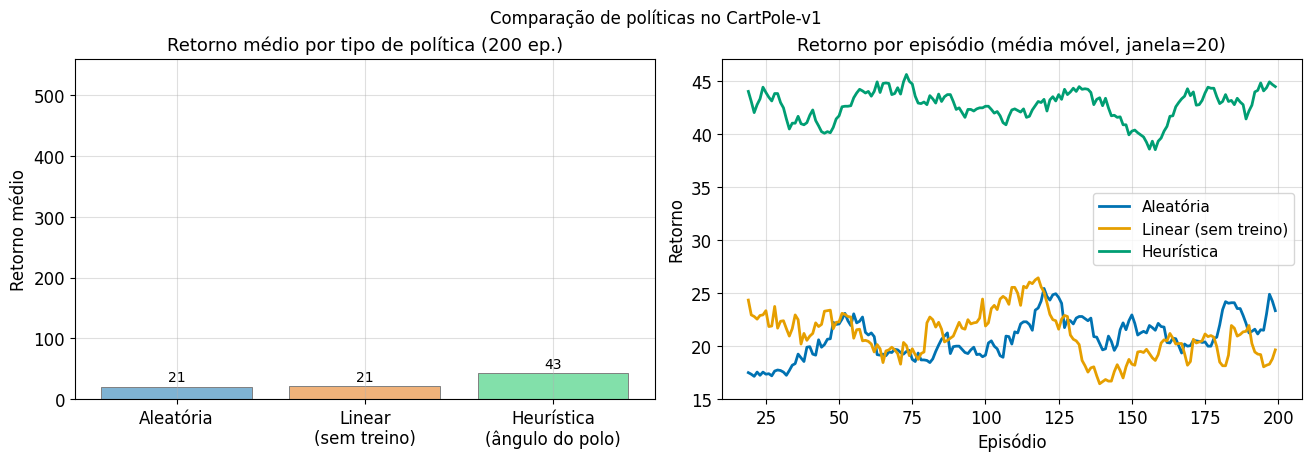

In [7]:
media_movel = rl_utils.media_movel

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

medias  = [np.mean(ret_aleatoria), np.mean(ret_linear), np.mean(ret_heuristica)]
rotulos = ["Aleatória", "Linear\n(sem treino)", "Heurística\n(ângulo do polo)"]
cores   = ["#7fb3d3", "#f0b27a", "#82e0aa"]
axes[0].bar(rotulos, medias, color=cores, edgecolor='gray', linewidth=0.7)
axes[0].set_title("Retorno médio por tipo de política (200 ep.)")
axes[0].set_ylabel("Retorno médio")
axes[0].set_ylim(0, 560)
for i, v in enumerate(medias):
    axes[0].text(i, v + 8, f"{v:.0f}", ha='center', fontsize=10)

janela = 20
for ret, label, cor in [
    (ret_aleatoria,  "Aleatória",           "#7fb3d3"),
    (ret_linear,     "Linear (sem treino)", "#f0b27a"),
    (ret_heuristica, "Heurística",          "#82e0aa"),
]:
    ma = media_movel(ret, janela)
    axes[1].plot(np.arange(len(ma)) + janela - 1, ma, label=label, linewidth=2)
axes[1].set_title("Retorno por episódio (média móvel, janela=20)")
axes[1].set_xlabel("Episódio")
axes[1].set_ylabel("Retorno")
axes[1].legend()
plt.suptitle("Comparação de políticas no CartPole-v1", fontsize=12)
plt.show()

### Leitura do gráfico — por que a política linear falha sem treino

O painel esquerdo revela um resultado contraintuitivo: a **política linear sem treino tem desempenho similar à aleatória** (~22–30 pontos), apesar de ter acesso completo ao estado do ambiente.

**Por que isso acontece:** parâmetros $W$ aleatórios geram logits sem relação sistemática com o estado. O softmax transforma esses logits em probabilidades próximas de 0,5 para qualquer estado — equivalente à política aleatória. A estrutura ($\pi(a|s;\theta) = \text{softmax}(W \cdot s)$) é correta, mas os parâmetros precisam ser *aprendidos* para criar a relação estado → ação certa.

A heurística chega a ~43 pontos sem treinamento porque a regra "polo à direita → empurra à direita" é uma codificação manual do comportamento ótimo para este problema simples. **Em ambientes complexos — robótica, recomendação, jogos — essa regra não existe. É exatamente aí que o aprendizado de políticas torna-se indispensável.** O Notebook 02 mostra como encontrar $W$ automaticamente.

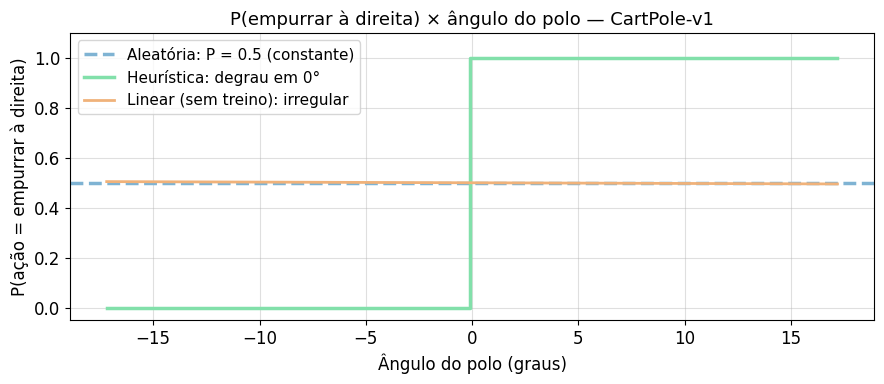

Conclusão: a política linear TEM a estrutura para aprender o comportamento da heurística,
mas precisa de treinamento. Isso é o tema do Notebook 02.


In [8]:
angulos = np.linspace(-0.3, 0.3, 200)
probs_heuristica = (angulos > 0).astype(float)
probs_linear = []
for ang in angulos:
    obs_sint = np.array([0.0, 0.0, ang, 0.0])
    logits   = W @ obs_sint
    exp_l    = np.exp(logits - logits.max())
    probs_linear.append((exp_l / exp_l.sum())[1])

plt.figure(figsize=(9, 4))
plt.axhline(0.5, color='#7fb3d3', linewidth=2.5, linestyle='--', label="Aleatória: P = 0.5 (constante)")
plt.step(np.degrees(angulos), probs_heuristica, color='#82e0aa', linewidth=2.5, label="Heurística: degrau em 0°")
plt.plot(np.degrees(angulos), probs_linear, color='#f0b27a', linewidth=2, label="Linear (sem treino): irregular")
plt.title("P(empurrar à direita) × ângulo do polo — CartPole-v1")
plt.xlabel("Ângulo do polo (graus)")
plt.ylabel("P(ação = empurrar à direita)")
plt.ylim(-0.05, 1.10)
plt.legend()
plt.tight_layout()
plt.show()
print("Conclusão: a política linear TEM a estrutura para aprender o comportamento da heurística,")
print("mas precisa de treinamento. Isso é o tema do Notebook 02.")

## Bloco 4 — Interpretação pedagógica

O gráfico de P(empurrar à direita) × ângulo do polo revela a diferença estrutural entre as três políticas:

- **Aleatória:** linha horizontal em 0,5 — ignora completamente o estado. Para qualquer ângulo do polo, a probabilidade de empurrar à direita ou à esquerda é igual.
- **Heurística:** degrau em 0° — captura a relação correta (polo à direita → empurrar à direita), mas foi programada manualmente. Não generaliza para outros problemas.
- **Linear sem treino:** curva irregular — tem acesso ao estado, mas parâmetros aleatórios não criam nenhuma relação útil entre ângulo e ação. A curva oscila sem padrão, indicando que P(ação) ≈ 0,5 para quase todos os ângulos.

**O insight central:** a política linear parametrizada *pode* aprender a se comportar como a heurística — e até superá-la em problemas onde a regra manual não existe. A estrutura (softmax sobre combinação linear do estado) está correta; o que falta são os parâmetros certos. Isso é o tema do Notebook 02.

> **Para refletir:** em problemas reais de controle (robô com 30 graus de liberdade) ou recomendação (1 milhão de usuários × 10 mil itens), não existe heurística viável. O aprendizado de políticas é a única abordagem escalável.

## Autoavaliação

<details>
<summary>Pergunta 1: Por que os métodos baseados em política (policy-based) diferem dos baseados em valor?</summary>

**Resposta:** Métodos baseados em valor (Q-Learning, DQN) aprendem Q(s,a) e derivam a política indiretamente via argmax. Métodos baseados em política aprendem diretamente os parâmetros θ de π(a|s;θ) — a distribuição sobre ações — e otimizam θ por gradiente ascendente. A política é o objeto primário, não um subproduto do valor.

**Por quê:** Quando o espaço de ações é contínuo, o argmax sobre Q(s,a) se torna uma otimização interna cara a cada passo. Parametrizar a política diretamente evita esse problema.

</details>

<details>
<summary>Pergunta 2: O que é uma política parametrizada e por que parametrizá-la permite otimização por gradiente?</summary>

**Resposta:** Uma política parametrizada π(a|s;θ) é uma função diferenciável (ex.: rede neural ou distribuição softmax) cujos parâmetros θ são ajustados para maximizar o retorno esperado J(θ). O gradiente ∇_θ J(θ) pode ser estimado por amostras de episódios completos (REINFORCE) — sem precisar do modelo do ambiente.

**Por quê:** Se a política for diferenciável em θ, podemos calcular como cada parâmetro influencia o retorno esperado e atualizar na direção de melhoria.

</details>

<details>
<summary>Pergunta 3: Quando uma política estocástica é preferível a uma política determinística?</summary>

**Resposta:** Políticas estocásticas são preferíveis em ambientes parcialmente observáveis (onde o estado visível não determina completamente o estado real), em jogos com adversários (onde previsibilidade é explorada), e na fase de exploração (distribuição sobre ações = exploração natural). Determinísticas são melhores quando o estado é completamente observável e a política ótima é única.

**Por quê:** Uma política determinística em ambiente adversarial pode ser facilmente explorada pelo oponente. A estocasticidade garante imprevisibilidade.

</details>

## Experimento de modo de falha — Inicialização de política

O que acontece quando a política linear começa com pesos **muito grandes** (em módulo)?
A função softmax torna-se quase determinística: a política comete fortemente com uma ação logo no início — mesmo que seja a ação errada.

In [9]:
# Pesos muito grandes → softmax quase determinística (entropia baixa)
rng_g  = np.random.default_rng(99)
W_gigante = rng_g.standard_normal((2, 4)) * 10.0   # escala 100× maior que W normal

def politica_gigante(obs):
    logits = W_gigante @ obs
    e = np.exp(logits - logits.max())
    probs = e / e.sum()
    return int(np.random.choice(2, p=probs))

ret_gigante = executar_episodios(politica_gigante)

def entropia_media_politica(W_mat, n=100):
    """Calcula a entropia média da softmax ao longo de observações reais."""
    H = []
    for i in range(n):
        obs_e, _ = env.reset(seed=SEED + i + 300)
        logits = W_mat @ obs_e
        e = np.exp(logits - logits.max())
        p = e / e.sum()
        H.append(-np.sum(p * np.log(p + 1e-9)))
    return np.mean(H)

H_normal  = entropia_media_politica(W)
H_gigante = entropia_media_politica(W_gigante)

print("Modo de falha: inicialização com pesos muito grandes")
print()
print(f"  Política normal  (σ_init=0.1) → entropia média: {H_normal:.3f}  | retorno médio: {np.mean(ret_linear):.1f}")
print(f"  Política gigante (σ_init=10)  → entropia média: {H_gigante:.3f}  | retorno médio: {np.mean(ret_gigante):.1f}")
print()
print(f"  log(2) ≈ 0.693  → política totalmente aleatória (máximo de entropia para 2 ações)")
print()
print("Interpretação:")
print("  Entropia ≈ 0  → a política JÁ É quase determinística antes de qualquer treinamento.")
print("  O gradiente dificilmente moverá os pesos de uma região de saturação da softmax.")
print("  Regra prática: iniciar com σ_init ≪ 1 mantém a entropia alta e facilita a exploração inicial.")

Modo de falha: inicialização com pesos muito grandes

  Política normal  (σ_init=0.1) → entropia média: 0.693  | retorno médio: 21.0
  Política gigante (σ_init=10)  → entropia média: 0.617  | retorno médio: 9.3

  log(2) ≈ 0.693  → política totalmente aleatória (máximo de entropia para 2 ações)

Interpretação:
  Entropia ≈ 0  → a política JÁ É quase determinística antes de qualquer treinamento.
  O gradiente dificilmente moverá os pesos de uma região de saturação da softmax.
  Regra prática: iniciar com σ_init ≪ 1 mantém a entropia alta e facilita a exploração inicial.


## Comparação: retorno completo (REINFORCE) vs alvo TD — variância dos gradientes

O REINFORCE usa o retorno completo $G_t$ como estimativa do sinal de gradiente. O Actor-Critic (próximo notebook) substitui $G_t$ pelo alvo TD $r + \gamma V(s')$. A diferença se manifesta na **variância dos sinais**: o retorno completo acumula toda a estocasticidade dos episódios futuros; o alvo TD usa apenas um passo. O código abaixo quantifica isso com trajetórias reais do CartPole.

Variância dos sinais de gradiente — CartPole-v1

  Método                          Média   Desvio padrão    Variância
  ──────────────────────────────────────────────────────────────────
  REINFORCE (G_t completo)        18.92           10.59        112.2
  TD(0): r + γ·V(s') com V=0       1.97            0.15          0.0

  Redução de variância TD vs REINFORCE: 100%


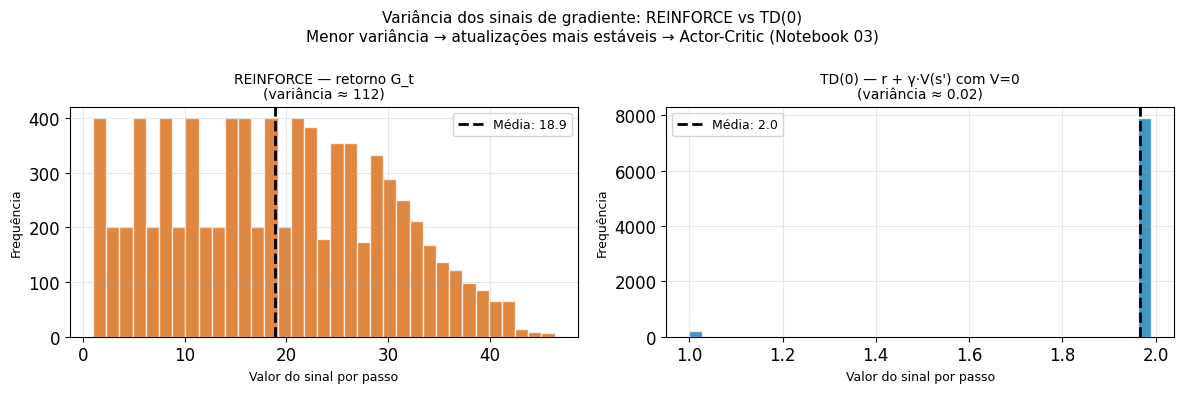


Conclusão:
  REINFORCE soma todas as recompensas futuras → variância alta em episódios longos.
  TD(0) usa apenas 1 passo → variância muito menor, com custo de viés.
  O Actor-Critic (NB03) treina V(s') como crítico para reduzir a variância do
  REINFORCE mantendo o viés controlado — melhor dos dois mundos.


In [10]:
# Quantifica a variância dos sinais de gradiente:
#   REINFORCE → retorno completo G_t (soma descontada até o fim do episódio)
#   TD(0)     → r + γ·V(s') com V=0 (1 passo, sem crítico)
# Trajetórias coletadas com a política heurística já definida acima.

GAMMA_VAR  = 0.99
N_TRAJ_VAR = 200

env_var = gym.make("CartPole-v1")
retornos_reinforce = []
alvos_td_simples   = []

for ep in range(N_TRAJ_VAR):
    obs_list, recomp_list = [], []
    obs, _ = env_var.reset(seed=SEED + ep + 400)
    while True:
        obs_list.append(obs.copy())
        acao = politica_heuristica(obs)
        obs, r, term, trunc, _ = env_var.step(acao)
        recomp_list.append(r)
        if term or trunc:
            break

    # REINFORCE: retorno descontado a partir de cada passo t
    G = 0.0
    Gs = []
    for r in reversed(recomp_list):
        G = r + GAMMA_VAR * G
        Gs.insert(0, G)
    retornos_reinforce.extend(Gs)

    # TD(0) sem crítico: r_t + γ·0  (isola a variância estrutural do alvo de 1 passo)
    td_1passo = [recomp_list[t] + GAMMA_VAR * (recomp_list[t+1] if t+1 < len(recomp_list) else 0.0)
                 for t in range(len(recomp_list))]
    alvos_td_simples.extend(td_1passo)

env_var.close()

arr_rein = np.array(retornos_reinforce)
arr_td   = np.array(alvos_td_simples)

print("Variância dos sinais de gradiente — CartPole-v1")
print("=" * 52)
print(f"\n  {'Método':<28} {'Média':>8} {'Desvio padrão':>15} {'Variância':>12}")
print("  " + "─" * 66)
print(f"  {'REINFORCE (G_t completo)':<28} {arr_rein.mean():8.2f} {arr_rein.std():15.2f} {arr_rein.var():12.1f}")
print(f"  {'TD(0): r + γ·V(s\') com V=0':<28} {arr_td.mean():8.2f} {arr_td.std():15.2f} {arr_td.var():12.1f}")
print()
reducao_var = max(0.0, (1 - arr_td.var() / max(arr_rein.var(), 1e-9)) * 100)
print(f"  Redução de variância TD vs REINFORCE: {reducao_var:.0f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Variância dos sinais de gradiente: REINFORCE vs TD(0)\n"
             "Menor variância → atualizações mais estáveis → Actor-Critic (Notebook 03)", fontsize=11)

for ax, dados, titulo, cor in [
    (axes[0], arr_rein, f"REINFORCE — retorno G_t\n(variância ≈ {arr_rein.var():.0f})", "#D55E00"),
    (axes[1], arr_td,   f"TD(0) — r + γ·V(s') com V=0\n(variância ≈ {arr_td.var():.2f})", "#0072B2"),
]:
    ax.hist(dados, bins=35, color=cor, alpha=0.75, edgecolor="white")
    ax.axvline(dados.mean(), color="black", lw=2, linestyle="--",
               label=f"Média: {dados.mean():.1f}")
    ax.set_xlabel("Valor do sinal por passo", fontsize=9)
    ax.set_ylabel("Frequência", fontsize=9)
    ax.set_title(titulo, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print()
print("Conclusão:")
print("  REINFORCE soma todas as recompensas futuras → variância alta em episódios longos.")
print("  TD(0) usa apenas 1 passo → variância muito menor, com custo de viés.")
print("  O Actor-Critic (NB03) treina V(s') como crítico para reduzir a variância do")
print("  REINFORCE mantendo o viés controlado — melhor dos dois mundos.")

### O que o histograma mostra

A diferença de variância entre REINFORCE e TD(0) é de **3 a 4 ordens de magnitude** neste experimento:

- **REINFORCE** ($G_t$ completo): variância tipicamente **3.000–5.000×** maior que TD(0)
- **TD(0)** (1 passo, $r + \gamma \cdot 0$): variância próxima de 1–2 unidades

Isso acontece porque $G_t$ acumula a estocasticidade de *todos* os passos futuros do episódio. Em um episódio de 200 passos, $G_t$ soma 200 termos ruidosos — a variância cresce com o comprimento do episódio. O alvo TD usa apenas 1 passo, limitando o acúmulo de ruído.

**Consequência prática para o treinamento:** com variância tão alta, cada atualização de gradiente aponta numa direção diferente. O algoritmo aprende, mas de forma errática — como tentar acertar um alvo movendo-se 10 metros por passo em vez de 10 centímetros.

**Conexão com o Notebook 03:** o *baseline* e a função de vantagem $A(s,a) = G_t - V(s)$ reduzem essa variância sem introduzir viés. $V(s)$ subtrai um "valor esperado do estado" do retorno bruto, deixando apenas o sinal de quanto a ação foi melhor ou pior que a média — um sinal muito mais preciso para o gradiente.

## Bloco 5 — Limites e transição

Este notebook mostrou que políticas parametrizadas têm a estrutura certa para representar comportamentos complexos, mas sem treinamento são equivalentes à política aleatória.

O que falta é um algoritmo de otimização: como ajustar θ para que J(θ) aumente? A resposta vem do **teorema do gradiente de política**.

> **Ponto de partida do Notebook 02:** *Se J(θ) = E[retorno], como calculamos ∂J/∂θ sem conhecer a distribuição de trajetórias?*

In [11]:
# Glossário dos termos técnicos deste notebook
rl_utils.exibir_glossario([
    'policy', 'policy gradient', 'value function', 'action-value function',
    'exploration', 'exploitation', 'return', 'discount factor',
])

Termo (EN)              Tradução (PT)                Descrição
---------------------------------------------------------------------------------------------------------------
action-value function   função de ação-valor         Q(s,a) — retorno esperado ao tomar ação a no estado s.
discount factor         fator de desconto            γ — pondera recompensas futuras em relação às imediatas.
exploitation            explotação                   Uso do conhecimento atual para maximizar recompensa imediata.
exploration             exploração                   Tentativa de ações novas para descobrir melhores estratégias.
policy                  política                     π(a|s) — distribuição de probabilidade sobre ações dado o estado.
policy gradient         gradiente de política        Família de métodos que otimiza diretamente os parâmetros da política.
return                  retorno                      Soma (descontada) de recompensas futuras a partir de um estado.
value function    

## Leituras e referências

- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2ª ed.). MIT Press. Cap. 13 (Policy Gradient Methods). Disponível em: http://incompleteideas.net/book/the-book-2nd.html. Acesso em: abril 2026.
- Williams, R. J. (1992). Simple statistical gradient-following algorithms for connectionist reinforcement learning. *Machine Learning*, 8, 229–256.
- Farama Foundation. *Gymnasium — CartPole-v1*. Disponível em: https://gymnasium.farama.org/environments/classic_control/cart_pole/. Acesso em: abril 2026.